In [21]:
# Step 1 - Import Libraries
# tensorflow is our main deep learning framework
import tensorflow as tf

# matplotlib lets us visualize images and training results
import matplotlib.pyplot as plt

# numpy helps us work with numbers and arrays
import numpy as np

# partial lets us create a "default" version of a function with preset settings
# we'll use this later to avoid repeating ourselves when building the CNN
from functools import partial

In [22]:
# Step 2 - Load the Data

# load training images from the train folder
# image_size resizes all images to 64x64 pixels so they're all the same size
# batch_size=32 means we feed 32 images at a time to the model during training
train_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:/Users/KOKO/Desktop/FruitClassifier/dataset/train",
    image_size=(224, 224),
    batch_size=32
)

# load test images — same settings, different folder
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:/Users/KOKO/Desktop/FruitClassifier/dataset/test",
    image_size=(224, 224),
    batch_size=32
)

Found 2301 files belonging to 10 classes.
Found 1025 files belonging to 10 classes.


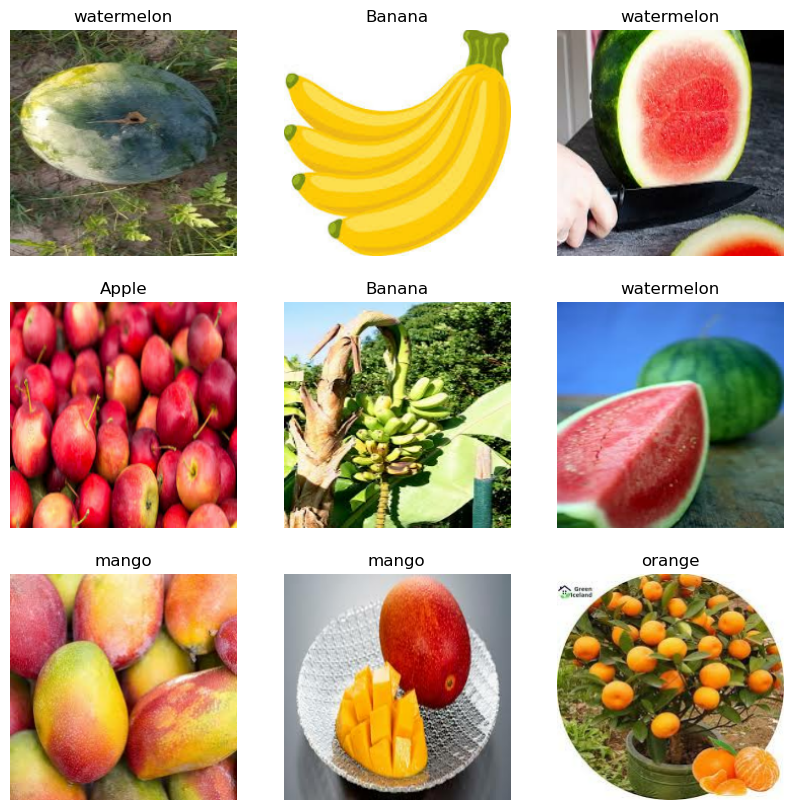

In [23]:
# Step 2.5 - Visualize Some Training Images
# this helps us make sure the data loaded correctly before we do anything else

# create a 10x10 figure to display our images
plt.figure(figsize=(10, 10))

# take(1) grabs just the first batch of 32 images
for images, labels in train_ds.take(1):
    
    # show 9 images in a 3x3 grid
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        # imshow expects values 0-255, so we convert back with astype("uint8")
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # class_names gives us the fruit name from the label number e.g. 0 → "Apple"
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [24]:
# Step 3 - Normalize the Data

# MobileNetV2 was trained with its own special preprocessing
# it expects pixel values between -1 and 1, not 0 and 1
# tf.keras.applications.mobilenet_v2.preprocess_input does this correctly
# it converts pixels from [0, 255] → [-1, 1]

train_ds = train_ds.map(lambda x, y: (tf.keras.applications.mobilenet_v2.preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (tf.keras.applications.mobilenet_v2.preprocess_input(x), y))

In [25]:
# Step 4 - Data Augmentation
# remember our overfitting problem? training 64% but validation only 46%?
# augmentation helps fix this by creating new variations of our training images
# so the model sees more diversity and can't just memorize the training set

data_augmentation = tf.keras.Sequential([
    # randomly flip the image horizontally (mirror effect)
    # an apple is still an apple whether flipped or not!
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    
    # randomly rotate the image slightly (max 5% of 360° = ~18 degrees)
    # a mango is still a mango even if slightly tilted
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    
    # randomly adjust the contrast slightly
    # helps the model handle different lighting conditions
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

In [26]:
# Step 5 - Load Pretrained MobileNetV2 (Transfer Learning)

# weights= local path because we downloaded the file manually
# include_top=False means we remove its last layer (which was for 1000 ImageNet classes)
# we'll add our own last layer for our 10 fruits instead
# input_shape=[224, 224, 3] tells it our image size (MobileNetV2 was trained on 224x224)
base_model = tf.keras.applications.MobileNetV2(
    weights=r"C:\Users\KOKO\Favorites\Downloads\mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5",
    include_top=False,
    input_shape=[224, 224, 3]  # ← fixed!
)

# freeze the base model — we don't want to change its pretrained weights yet
# it already knows how to detect shapes, edges, textures
# we just want to use that knowledge, not destroy it!
base_model.trainable = False

print("Base model loaded and frozen ✅")
print(f"Total layers: {len(base_model.layers)}")

Base model loaded and frozen ✅
Total layers: 154


In [27]:
# Step 6 - Build the Transfer Learning Model

model = tf.keras.Sequential([
    # augmentation layer first
    data_augmentation,
    
    # the pretrained MobileNetV2 base — all 154 layers of knowledge!
    base_model,
    
    # GlobalAveragePooling squashes the output of MobileNetV2
    # from (7, 7, 1280) → (1280,) — a flat vector of 1280 features
    tf.keras.layers.GlobalAveragePooling2D(),
    
    # Dropout to prevent overfitting
    tf.keras.layers.Dropout(0.2),
    
    # our final layer — 10 neurons for 10 fruits
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
# Step 7 - Train the Model
history = model.fit(train_ds, epochs=20, validation_data=test_ds)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 425ms/step - accuracy: 0.5502 - loss: 1.3687 - val_accuracy: 0.6000 - val_loss: 1.4223
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 421ms/step - accuracy: 0.7862 - loss: 0.6762 - val_accuracy: 0.6459 - val_loss: 1.4213
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 405ms/step - accuracy: 0.8275 - loss: 0.5170 - val_accuracy: 0.6595 - val_loss: 1.4822
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 421ms/step - accuracy: 0.8544 - loss: 0.4314 - val_accuracy: 0.6693 - val_loss: 1.5126
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 406ms/step - accuracy: 0.8774 - loss: 0.3850 - val_accuracy: 0.6683 - val_loss: 1.5656
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 423ms/step - accuracy: 0.8983 - loss: 0.3329 - val_accuracy: 0.6780 - val_loss: 1.5984
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 406ms/step - accuracy: 0.9083 - loss: 0.3007 - val_accuracy: 0.6780 - val_loss: 1.6340
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 422ms/step - accuracy: 0.9161 - loss: 0.2771 - val_accu

In [29]:
# Step 8 - Fine Tuning
# now that the top layers (our fruit head) have learned the basics
# we can unfreeze the top layers of MobileNetV2 and let them adapt to our fruits

# unfreeze the whole base model first
base_model.trainable = True

# then freeze everything except the last 30 layers
# the last 30 layers are the "high level" layers closest to our output
# they need to adapt to fruits, the early layers (edges, shapes) don't
for layer in base_model.layers[:-30]:
    layer.trainable = False

# recompile the model with a much smaller learning rate
# very important! if learning rate is too high we'll destroy the pretrained weights
# 1e-5 = 0.00001 → tiny steps so we don't forget what MobileNetV2 already knows
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"]
)

# train for 10 more epochs on top of what we already learned
history_fine = model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 486ms/step - accuracy: 0.7970 - loss: 0.6112 - val_accuracy: 0.6780 - val_loss: 1.9516
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 465ms/step - accuracy: 0.8566 - loss: 0.4247 - val_accuracy: 0.6780 - val_loss: 1.9719
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 481ms/step - accuracy: 0.8996 - loss: 0.3294 - val_accuracy: 0.6761 - val_loss: 1.9999
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 463ms/step - accuracy: 0.9013 - loss: 0.2863 - val_accuracy: 0.6800 - val_loss: 2.0308
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 480ms/step - accuracy: 0.9148 - loss: 0.2607 - val_accuracy: 0.6810 - val_loss: 2.0576
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 464ms/step - accuracy: 0.9296 - loss: 0.2172 - val_accuracy: 0.6810 - val_loss: 2.0769
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 493ms/step - accuracy: 0.9348 - loss: 0.2029 - val_accuracy: 0.6790 - val_loss: 2.0998
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 473ms/step - accuracy: 0.9422 - loss: 0.1888 - val_accu